# Reusable Template: Logistic Regression Decision-Boundary Analysis
## For any 2-feature binary economic classification problem

Copy this notebook and edit the `# >>> EDIT` blocks to apply the same workflow to a new problem
(recession prediction, bank-failure prediction, sovereign default, labor-force participation, loan approval, ...).
Everything else is reusable machinery.

## 0. Describe your problem
*(Fill this in before touching code — it disciplines the rest of the notebook.)*

- **Outcome $y$:** what does $y=1$ mean? what does $y=0$ mean? _(e.g. y=1: country enters a currency crisis within 12 months)_
- **Feature $x_0$:** name + units + expected sign of its effect on $y=1$. _(e.g. reserves/imports ratio, expect negative)_
- **Feature $x_1$:** name + units + expected sign. _(e.g. current-account deficit/GDP, expect positive)_
- **Where do the parameters $(w_0, w_1, b)$ come from?** a paper you're replicating, a model you fit yourself, or illustrative "suppose" values for teaching?
- **What decision does the classifier support?** (e.g. flag for supervisory review, price a loan, trigger a hedge)


## 1. Setup — reusable helper functions (edit only if you need extra plot styling)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    """Numerically stable sigmoid / logistic function."""
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def plot_data(X, y, ax, pos_label="Default (y=1)", neg_label="Repaid (y=0)", s=90):
    """Scatter-plot a 2-feature binary-outcome dataset."""
    y = np.array(y).reshape(-1)
    pos = y == 1
    neg = y == 0
    ax.scatter(X[pos, 0], X[pos, 1], marker='x', s=s, c='crimson', linewidths=2, label=pos_label)
    ax.scatter(X[neg, 0], X[neg, 1], marker='o', s=s, facecolors='none',
               edgecolors='steelblue', linewidths=2, label=neg_label)
    ax.legend(loc='best')

def draw_vthresh(ax, x):
    """Shade g(z)<0.5 vs g(z)>=0.5 either side of z=x on a sigmoid plot."""
    ylim, xlim = ax.get_ylim(), ax.get_xlim()
    ax.fill_between([xlim[0], x], ylim[1], alpha=0.15, color='steelblue')
    ax.fill_between([x, xlim[1]], ylim[1], alpha=0.15, color='crimson')
    ax.axvline(x, color='k', ls='--', lw=1)
    ax.set_xlim(xlim); ax.set_ylim(ylim)

def plot_linear_boundary(w, b, ax, x_range=(0, 4), color='seagreen', label='Decision boundary'):
    """Plot w0*x0 + w1*x1 + b = 0 and shade the predicted-0 region."""
    x0 = np.linspace(x_range[0], x_range[1], 200)
    x1 = -(w[0] * x0 + b) / w[1]
    ax.plot(x0, x1, c=color, lw=2, label=label)
    ax.fill_between(x0, x1, ax.get_ylim()[0], alpha=0.12, color=color)
    return x0, x1

def plot_polynomial_boundary(f_boundary, ax, x_range=(0, 4), n=300, color='darkorange', label='Decision boundary'):
    # Plot x1 = f_boundary(x0) for a non-linear boundary and shade below it.
    x0 = np.linspace(x_range[0], x_range[1], n)
    x1 = f_boundary(x0)
    ax.plot(x0, x1, c=color, lw=2, label=label)
    ax.fill_between(x0, x1, ax.get_ylim()[0], alpha=0.12, color=color)
    return x0, x1

def classify(w, b, x):
    # Predicted class (0/1) and probability for a single point x (array-like, length k).
    p = sigmoid(np.dot(w, x) + b)
    return int(p >= 0.5), p

def odds_ratios(w, feature_names=None):
    # e^w_j for each feature: how much the odds multiply per 1-unit increase in x_j.
    ors = np.exp(w)
    if feature_names is not None:
        return dict(zip(feature_names, ors))
    return ors

def marginal_effect(w, b, x, j):
    # Partial derivative of predicted probability w.r.t. feature j, evaluated at point x.
    p = sigmoid(np.dot(w, x) + b)
    return w[j] * p * (1 - p)


## 2. STEP 1 — Load / define your data

Replace the arrays below with your own dataset. `X` must be shape `(n_samples, 2)`; `y` must be shape `(n_samples, 1)` with values in {0, 1}.

If you have a CSV instead of hand-typed data, use:
```python
import pandas as pd
df = pd.read_csv("your_file.csv")
X = df[["feature_0_name", "feature_1_name"]].to_numpy()
y = df["outcome_name"].to_numpy().reshape(-1, 1)
```

In [2]:
# >>> EDIT: your feature names (used in axis labels & tables throughout)
feature_names = ["x0_name_here", "x1_name_here"]
pos_label = "y=1 label here"   # e.g. "Crisis"
neg_label = "y=0 label here"   # e.g. "No crisis"

# >>> EDIT: your data (or load from a file as shown above)
X = np.array([
    [0.5, 1.5],
    [1.0, 1.0],
    [1.5, 0.5],
    [3.0, 0.5],
    [2.0, 2.0],
    [1.0, 2.5],
])
y = np.array([0, 0, 0, 1, 1, 1]).reshape(-1, 1)

print("X shape:", X.shape, " y shape:", y.shape)


X shape: (6, 2)  y shape: (6, 1)


## 3. STEP 2 — Visualize the raw data

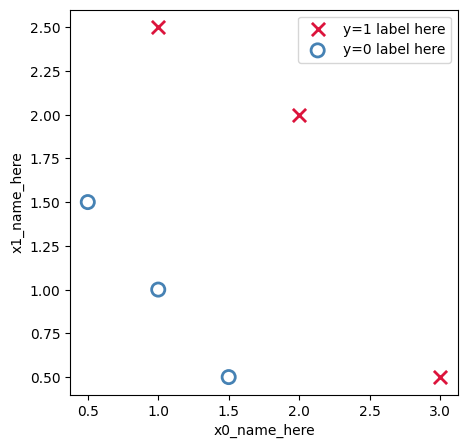

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
plot_data(X, y, ax, pos_label=pos_label, neg_label=neg_label)
ax.set_xlabel(feature_names[0])
ax.set_ylabel(feature_names[1])
plt.show()


## 4. STEP 3 — Set (or fit) the model parameters

**Option A — you already have parameters** (from a paper, a prior fit, or an illustrative "suppose"):
edit `w` and `b` directly below.

**Option B — fit them yourself** on your own labeled data with scikit-learn (uncomment):
```python
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X, y.ravel())
w, b = clf.coef_[0], clf.intercept_[0]
```

In [4]:
# >>> EDIT: either hard-code parameters, or fit them (see markdown above)
w = np.array([1.0, 1.0])   # >>> EDIT
b = -3.0                    # >>> EDIT

print("w:", w, " b:", b)
print("odds ratios:", odds_ratios(w, feature_names))


w: [1. 1.]  b: -3.0
odds ratios: {'x0_name_here': np.float64(2.718281828459045), 'x1_name_here': np.float64(2.718281828459045)}


## 5. STEP 4 — Sigmoid / threshold refresher (boilerplate — usually no edits needed)

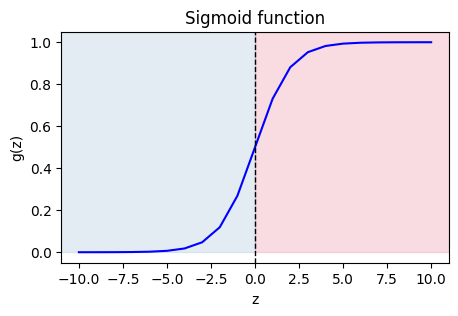

In [5]:
z = np.arange(-10, 11)
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(z, sigmoid(z), c="b")
draw_vthresh(ax, 0)
ax.set_title("Sigmoid function")
ax.set_xlabel("z")
ax.set_ylabel("g(z)")
plt.show()


## 6. STEP 5 — Plot the (linear) decision boundary

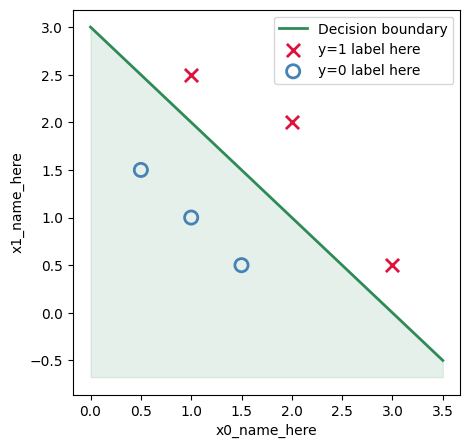

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

x0_min, x0_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
plot_linear_boundary(w, b, ax, x_range=(x0_min, x0_max))
plot_data(X, y, ax, pos_label=pos_label, neg_label=neg_label)

ax.set_xlabel(feature_names[0])
ax.set_ylabel(feature_names[1])
ax.legend(loc="best")
plt.show()


## 7. STEP 6 — Interpret the coefficients in your domain

Fill in this cell for your specific application:

- **Sign check:** does the sign of each $w_j$ match economic intuition (from Step 0)? If not, investigate — possible omitted-variable bias, wrong functional form, or a data problem.
- **Odds ratio ($e^{w_j}$):** printed above — "for a 1-unit increase in `feature_names[j]`, the odds of `pos_label` are multiplied by ___".
- **Boundary slope** $-w_0/w_1$: the implied trade-off/substitution rate between your two features at the 50% probability threshold.
- **Marginal effect at a point of interest** (e.g. the sample mean, or a policy-relevant value):
```python
x_of_interest = X.mean(axis=0)
for j, name in enumerate(feature_names):
    print(name, "marginal effect:", marginal_effect(w, b, x_of_interest, j))
```
- **Classify a new observation:**
```python
cls, p = classify(w, b, [value_for_x0, value_for_x1])
print(f"Predicted class={cls}, P({pos_label})={p:.3f}")
```

*(Your written interpretation here)*

In [7]:
x_of_interest = X.mean(axis=0)
for j, name in enumerate(feature_names):
    print(name, "marginal effect at mean:", round(marginal_effect(w, b, x_of_interest, j), 4))


x0_name_here marginal effect at mean: 0.2483
x1_name_here marginal effect at mean: 0.2483


## 8. STEP 7 (optional) — Non-linear boundary

If Step 6 suggests the linear boundary doesn't capture the relationship well (e.g. residual patterns, a theoretical reason to expect acceleration/threshold effects), define a non-linear boundary function and re-plot.

Example: quadratic term on $x_0$, boundary solved analytically as $x_1 = c - a\,x_0^2$ for some model $f(x)=g(a x_0^2 + x_1 + c')$. For boundaries you *can't* solve in closed form (e.g. more than 2 engineered features collapsed to 2D, or logistic regression fit on polynomial features), evaluate the model on a grid instead — see the commented block below.

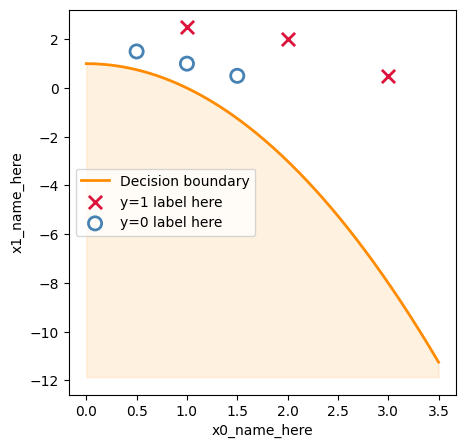

In [8]:
# >>> EDIT: analytic non-linear boundary example (edit the function or delete this cell)
def my_boundary(x0):
    return 1 - x0**2   # example: x1 = 1 - x0^2

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
plot_polynomial_boundary(my_boundary, ax, x_range=(x0_min, x0_max))
plot_data(X, y, ax, pos_label=pos_label, neg_label=neg_label)
ax.set_xlabel(feature_names[0])
ax.set_ylabel(feature_names[1])
ax.legend(loc="best")
plt.show()

# --- Alternative: grid-based boundary for a model with no closed form ---
# from sklearn.linear_model import LogisticRegression
# X_poly = np.column_stack([X[:,0], X[:,1], X[:,0]**2, X[:,0]*X[:,1]])
# clf = LogisticRegression().fit(X_poly, y.ravel())
# xx0, xx1 = np.meshgrid(np.linspace(x0_min, x0_max, 200), np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 200))
# grid = np.column_stack([xx0.ravel(), xx1.ravel(), xx0.ravel()**2, xx0.ravel()*xx1.ravel()])
# probs = clf.predict_proba(grid)[:, 1].reshape(xx0.shape)
# fig, ax = plt.subplots(figsize=(5,5))
# ax.contour(xx0, xx1, probs, levels=[0.5], colors='darkorange')
# ax.contourf(xx0, xx1, probs, levels=[0,0.5,1], colors=['steelblue','crimson'], alpha=0.12)
# plot_data(X, y, ax, pos_label=pos_label, neg_label=neg_label)
# plt.show()


## 9. Checklist before you trust this analysis
- [ ] Coefficient signs match economic theory (or you can explain why not)
- [ ] No perfect/quasi-separation causing unstable coefficients (check `LogisticRegression` didn't warn about convergence)
- [ ] Sample size is adequate relative to number of features (rule of thumb: ≥10–20 events of the rarer class per feature)
- [ ] You've checked out-of-sample performance if this will be used for actual prediction (train/test split or cross-validation), not just in-sample fit
- [ ] You are not claiming causal effects from these coefficients unless you have an identification strategy
- [ ] Class imbalance handled appropriately (weighted loss, or evaluate with precision/recall/AUC rather than accuracy) if the outcome is rare
